In [1]:
import numpy as np
import matplotlib.pyplot as plt

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (IAI_TO_IMAGE_CLASSES, 
                                          aluminium_regions, 
                                          path_input_data,
                                          models_output_dict,
                                          REGION_TO_CLASS_DICT)

In [2]:
# Aluminium
aluminium = ResourceModel(resource_group = 'metals', resource = 'aluminium', 
                       image_mat_available = True, start_year = 1998, 
                       scenario = 'SSP2_M_CP', end_year = 2024
                       )

# removed outlier reginos so they are not represented in the global fit
all_regions = ['Africa',
        'Estimated Unreported to IAI', 
        'Gulf Cooperation Council',
        'North America', 
        'Russia & Eastern Europe', 
        'South America',
        'Western & Central Europe',
        'Japan',
        'Asia (ex China)',
        'Oceania',
        'China (Estimated)']

russia = ['Russia & Eastern Europe']

north_america = ['North America']

europe = ['Western & Central Europe', 'Japan', 'Oceania']

# own category because fitting otherwise somehow not possible
china = ['China (Estimated)', 'Gulf Cooperation Council']

# will be fitted to global curve or according to IMAGE Mat with some additions
rest = ['Africa',
        'Estimated Unreported to IAI', 
        'South America',
        'Asia (ex China)']

aluminium_regions = {
    'all_regions' : all_regions,
    'russia' : russia,
    'north_america' : north_america,
    'china' : china,
    'europe' : europe
}

aluminium.data_grouped_regions(regions_grouping = aluminium_regions) 

In [3]:
aluminium.sum_IMAGE_drivers_regions(IAI_TO_IMAGE_CLASSES)
aluminium.match_MAT_data_to_regions_year(match_external_regions=True)
aluminium.calculate_historic_other_fraction()

In [4]:
# Deal with negative values in other fraction BEFORE recalculation of other fraction consumption

# 1) Africa: for all negative values: assumption that apparent MAT is 60% of total consumption (mean until 2017)
# Share of IAMGE MAT data to total consumption
share = (aluminium.image_mat_material_regions.loc[:2017]/aluminium.historic_consumption_data.loc[:2017]*100).mean()
# starting at 2017 (when negative values start):
aluminium.image_mat_material_regions.loc[2017:, 'Africa'] = aluminium.historic_consumption_data.loc[2017:, 'Africa'] * share['Africa'] / 100

# 4) North America
# problem starts at 2015, so take share mean of IMAGE Mat data before that and apply it to 2015-2024
share_na = (aluminium.image_mat_material_regions.loc[:2015]/aluminium.historic_consumption_data.loc[:2015]*100).mean()
aluminium.image_mat_material_regions.loc[:, 'North America'] = aluminium.historic_consumption_data.loc[:, 'North America'] * share_na['North America'] / 100

# 6) South America: assume that share of Mat until 2010 is correct and that apparent consumption needs to be adjusted accordingly 
share_sa = (aluminium.image_mat_material_regions.loc[:2010, 'South America'] / aluminium.historic_consumption_data.loc[:2010, 'South America']).mean()
aluminium.historic_consumption_data.loc[:, 'South America'] = aluminium.image_mat_material_regions.loc[:, 'South America'] / share_sa

# Deal with negative values in other fraction AFTER recalculation of other fraction consumption
# redo calculation of historic other fraction consumption 
aluminium.calculate_historic_other_fraction()

# 2) rest of Asia: 
# per capita consmption of total data is too low compared to other regions, so we assume that IMAGE Mat is correct
# --> will be fitted to global curve 
# 3) Estimated Unreported to IAI: assume that IMAGE Mat is correct (these are mostly IMAGE region 6 regions)
# Most are small island territories, overseas territories or constituent countries mainly linked to France
# --> will be fitted to global curve 

# 5) Gulf Cooperation Council: remove negative values to nan, no problems in more recent years
# & Finally check the whole dataframe for single negative values and make them NaN
aluminium.historic_other_fraction_consumption[aluminium.historic_other_fraction_consumption < 0] = np.nan

In [5]:
aluminium.historic_other_fraction_consumption

,Africa,Asia (ex China),China (Estimated),Estimated Unreported to IAI,Gulf Cooperation Council,Japan,North America,Oceania,Russia & Eastern Europe,South America,Western & Central Europe
1988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Fit models
aluminium.calculate_regressors(aluminium.historic_other_fraction_consumption)

best_rmse_models= {
    'all_regions' : 'gompertz model',
    'russia' : 'gompertz model',
    'north_america' : 'gompertz model',
    'china' : 'gompertz model',
    'europe' : 'gompertz model'}

bounds = {
    'all_regions' : ([0, 0, 0], [10, 10, 10]),
    'russia' : ([0, 1, 1], [10, 10, 10]),
    'north_america' : ([0, 1, 1], [10, 10, 10]),
    'china' : ([0, 0, 0], [0.03, 10, 10]),
    'europe' : ([0, 0, 0], [10, 10, 10])
}

aluminium.fit_models(best_rmse_models, bounds)



# add regions to regions model match that are not in there yet becaused they are fitted to the global average
for key in IAI_TO_IMAGE_CLASSES.keys():
    if key not in aluminium.region_model_match:
        aluminium.region_model_match[key] = aluminium.model_groups.get("all_regions")[6]

C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return 

In [7]:
# Projections
aluminium.project_on_total(list(IAI_TO_IMAGE_CLASSES.keys()), start_year_projection=2012)
# start projectino from 2012 on because for some regions the data is not available before that

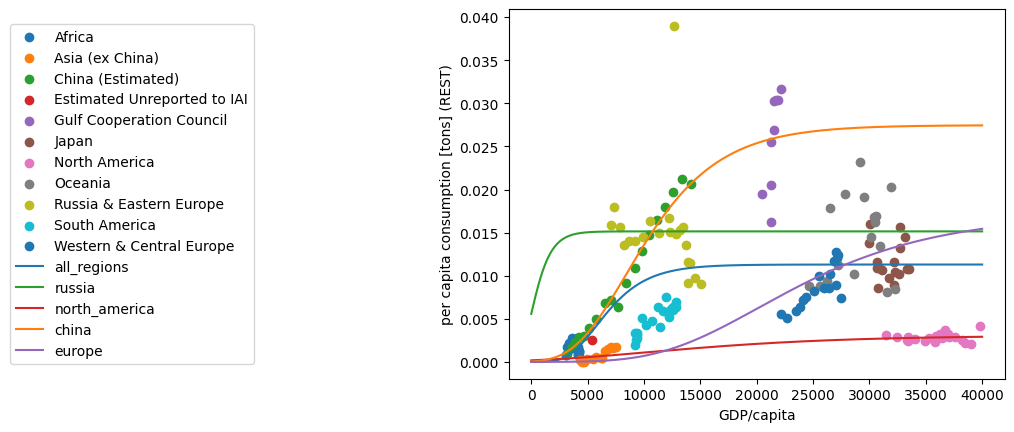

In [8]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis only for years that were fitted


color_dict_fits = {
    'all_regions' : '#1f77b4',  # blue
    'russia' : '#2ca02c',  # green
    'north_america' : '#d62728',  # red
    'china' : '#ff7f0e',  # orange
    'europe' : '#9467bd'  # purple

}


fig, ax = plt.subplots()             # Create a figure containing a single Axes.

for region in aluminium.cons_capita.columns:
    ax.scatter(aluminium.gdp_pc[region], 
               aluminium.cons_capita[region], 
               label = region)
    
    
for grouping in aluminium_regions.keys():
    model = aluminium.model_groups[grouping][models_output_dict[aluminium.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 40000).reshape(-1, 1)),
            label = grouping,
            color = color_dict_fits[grouping])

ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")



ax.legend(loc = 'right', bbox_to_anchor=(-0.5, 0.5))

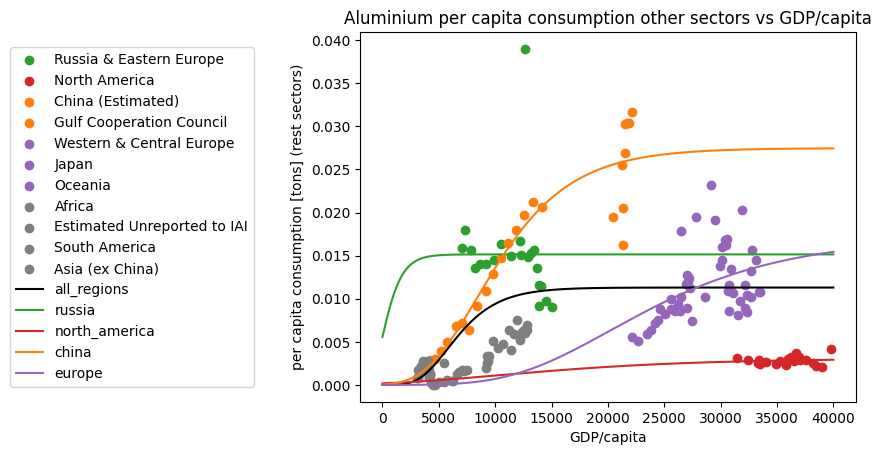

In [9]:
color_dict = {
    'all_regions' : "#000000",  # blue
    'russia' : '#2ca02c',  # green  
    'north_america' : '#d62728',  # red
    'china' :  '#ff7f0e',  # orange
    'europe' : '#9467bd',  # purple
    'rest' : '#7f7f7f'  # grey for rest of regions
}


fig, ax = plt.subplots()

for key, regions in aluminium_regions.items():
    if key == 'all_regions':
        continue
    for region in regions:
        ax.scatter(aluminium.gdp_pc[region], 
                aluminium.cons_capita[region], 
                label = region,
                color = color_dict[key])

for region in rest:
    ax.scatter(aluminium.gdp_pc[region], 
               aluminium.cons_capita[region], 
               label = region,
               color = color_dict['rest'])
    
for grouping in aluminium_regions.keys():
    model = aluminium.model_groups[grouping][models_output_dict[aluminium.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 40000).reshape(-1, 1)),
            label = grouping,
            color = color_dict[grouping])

ax.set_ylabel("per capita consumption [tons] (rest sectors)")
ax.set_xlabel("GDP/capita")
ax.set_title("Aluminium per capita consumption other sectors vs GDP/capita")

plt.legend(loc = 'right', bbox_to_anchor=(-0.2, 0.5))
    

In [10]:
aluminium.smooth_out_interpolation_all(10, 2012)

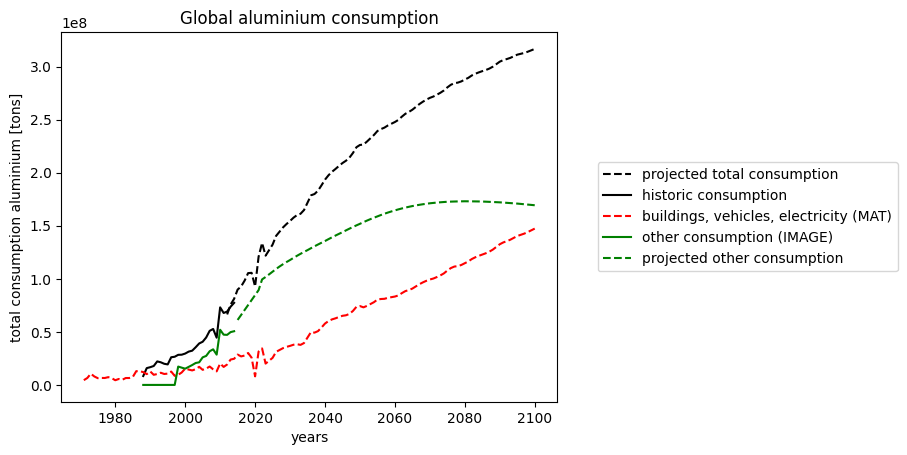

In [11]:
#Plot total consumption global

fig, ax = plt.subplots()             # Create a figure containing a single Axes.

ax.plot(aluminium.projection_per_region_total.sum(axis = 1) + aluminium.image_mat_data.sum(axis = 1).loc[2012:], 
        linestyle = '--', color = 'black', label = 'projected total consumption')

ax.plot(aluminium.historic_consumption_data.loc[:2014].sum(axis = 1),
        linestyle = '-', color = 'black', label = 'historic consumption')  

ax.plot(aluminium.image_mat_data.sum(axis = 1).loc[1971:],
        linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')

ax.plot(aluminium.historic_other_fraction_consumption.loc[:2014].sum(axis = 1),
        linestyle = '-', color = 'green', label = 'other consumption (IMAGE)')

ax.plot(aluminium.projection_per_region_total.loc[2015: ].sum(axis = 1),
        linestyle = '--', color = 'green', label = 'projected other consumption')

ax.set_ylabel("total consumption aluminium [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global aluminium consumption")
ax.legend(loc = 'right', bbox_to_anchor=(1.7, 0.5))

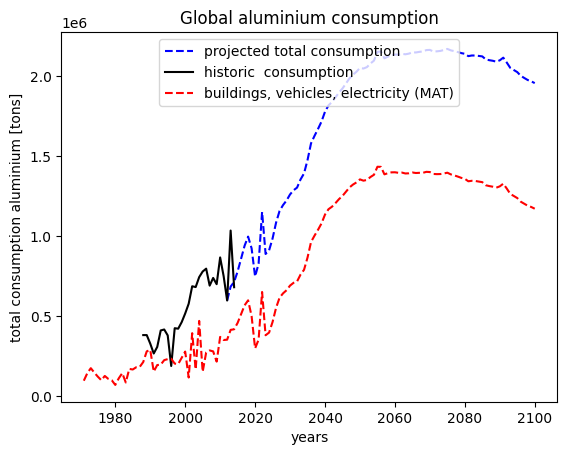

In [12]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.

region = 'Oceania'

ax.plot(aluminium.projection_per_region_total[region].loc[2012:, ] + aluminium.image_mat_material_regions_total[region].loc[2012:, ],
linestyle = '--', color = 'blue', label = 'projected total consumption')

ax.plot(aluminium.historic_consumption_data[region],
        linestyle = '-', color = 'black', label = 'historic  consumption')  

ax.plot(aluminium.image_mat_material_regions_total[region].loc[1971:],
        linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')

ax.set_ylabel("total consumption aluminium [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global aluminium consumption")
ax.legend(loc = 'upper center')

In [13]:
# # distribute regios model match to all regions

# IMAGE_region_model_match = {}

# for groups in aluminium.region_model_match.keys():
#     for region in IAI_TO_IMAGE_CLASSES[groups]:
#         IMAGE_region_model_match[region] = aluminium.region_model_match[groups]


# aluminium.region_model_match = IMAGE_region_model_match